# Review Pipeline Analysis

In [1]:
from pathlib import Path
import json
import re
import sqlite3
import statistics
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import ollama
import numpy as np
import random
from scipy import stats
import plotly.graph_objects as go
REVIEW_OUTPUTS_DIRS = [Path('./review_outputs_iter2/qwen2_5_7b'),
                       Path('./review_outputs_iter2/qwen3_5_9b'), 
                       Path('./review_outputs_iter2/qwen3_8b'), 
                       Path('./review_outputs_iter2/llama3_1_8b'), 
                       Path('./review_outputs_iter2/phi4_reasoning_14b'), 
                       Path('./review_outputs_iter2/apertus'), 
                       Path('./review_outputs_iter2/qwen3_14b')]
ICLR_DB_PATH = 'out_general/iclr2019.sqlite'
pd.set_option('display.max_colwidth', 80)

## Load Data

In [2]:
def load_review_files(directories: list[Path]) -> list[dict]:
    data = []
    for directory in directories:
        files = sorted(directory.glob('*.review_pipeline.json'))
        if not files:
            print(f'Warning: no *.review_pipeline.json files found in {directory}')
            continue
        for path in files:
            with path.open('r', encoding='utf-8') as f:
                paper_data = json.load(f)
            paper_data['source_review_dir'] = str(directory)
            paper_data['generated_paper_model'] = directory.name
            paper_data['source_file'] = str(path)
            data.append(paper_data)
        print(f'Loaded {len(files)} paper review files from {directory}')
    if not data:
        raise FileNotFoundError('No *.review_pipeline.json files found in any configured directory')
    print(f'Loaded {len(data)} paper review files in total')
    return data
papers_raw = load_review_files(REVIEW_OUTPUTS_DIRS)

Loaded 40 paper review files from review_outputs_iter2/qwen2_5_7b
Loaded 40 paper review files from review_outputs_iter2/qwen3_5_9b
Loaded 40 paper review files from review_outputs_iter2/qwen3_8b
Loaded 40 paper review files from review_outputs_iter2/llama3_1_8b
Loaded 40 paper review files from review_outputs_iter2/phi4_reasoning_14b
Loaded 40 paper review files from review_outputs_iter2/apertus
Loaded 40 paper review files from review_outputs_iter2/qwen3_14b
Loaded 280 paper review files in total


In [3]:
def word_count(text: str) -> int:
    return len(text.split())
review_rows = []
paper_rows = []
for paper in papers_raw:
    paper_id = paper['paper_id']
    reviewer_ratings = []
    for run in paper['reviews']:
        official = run['official_review']
        rating = official.get('rating')
        reviewer_ratings.append(rating)
        review_rows.append({'paper_id': paper_id, 'reviewer_model': official.get('reviewer_model'), 'title': official.get('title', ''), 'rating': rating, 'review_word_count': word_count(official.get('review', '')), 'title_word_count': word_count(official.get('title', '')), 'num_extracted_strengths': len(official.get('extracted_strengths', [])), 'num_extracted_weaknesses': len(official.get('extracted_weaknesses', [])), 'num_retrieved_chunks': len(run.get('retrieved_chunks', [])), 'official_review_seconds': run.get('timings_seconds', {}).get('official_review')})
    meta = paper.get('meta_review', {})
    paper_rows.append({'paper_id': paper_id, 'area_chair_model': paper.get('area_chair_model'), 'decision': meta.get('decision'), 'mean_rating': statistics.mean(reviewer_ratings) if reviewer_ratings else None, 'std_rating': statistics.pstdev(reviewer_ratings) if len(reviewer_ratings) > 1 else 0.0, 'min_rating': min(reviewer_ratings) if reviewer_ratings else None, 'max_rating': max(reviewer_ratings) if reviewer_ratings else None, 'num_reviewers': len(reviewer_ratings)})
reviews_df = pd.DataFrame(review_rows)
papers_df = pd.DataFrame(paper_rows)
print(f'reviews_df: {len(reviews_df)} rows (one per reviewer per paper)')
print(f'papers_df:  {len(papers_df)} rows (one per paper)')
reviews_df.head()

reviews_df: 840 rows (one per reviewer per paper)
papers_df:  280 rows (one per paper)


,paper_id,reviewer_model,title,rating,review_word_count,title_word_count,num_extracted_strengths,num_extracted_weaknesses,num_retrieved_chunks,official_review_seconds
0,idea_001_02,llama3.1:8b,The paper introduces a novel framework for quantifying adversarial sensitivi...,8,272,16,3,2,3,20.39
1,idea_001_02,qwen3:14b,The paper introduces a novel framework for quantifying adversarial sensitivi...,7,408,26,3,2,3,29.38
2,idea_001_02,phi4-reasoning:14b,Attention-Based Vulnerabilities: A Framework for Quantifying Adversarial Sen...,6,206,21,3,3,3,27.70
3,idea_001_05,llama3.1:8b,Theoretical Examination of Adversarial Perturbations in Vision Transformers ...,6,284,20,2,2,3,21.63
4,idea_001_05,qwen3:14b,The paper provides a theoretical analysis of how self-attention layers in vi...,7,363,33,2,2,3,29.28


## Resolve Generator Model

In [4]:
ASSEMBLED_PAPERS_BASE_DIR = None

def resolve_paper_path(input_path: str) -> Path:
    p = Path(input_path)
    if ASSEMBLED_PAPERS_BASE_DIR is not None and (not p.exists()):
        p = Path(ASSEMBLED_PAPERS_BASE_DIR) / p.name
    return p
paper_generator_map = {}
n_unresolved = 0
for paper in papers_raw:
    paper_id = paper['paper_id']
    input_path = paper.get('input_path')
    generator_model = None
    if input_path:
        resolved = resolve_paper_path(input_path)
        try:
            with resolved.open('r', encoding='utf-8') as f:
                original_paper = json.load(f)
            generator_model = original_paper.get('model')
        except (FileNotFoundError, json.JSONDecodeError):
            n_unresolved += 1
    paper_generator_map[paper_id] = generator_model
reviews_df['generator_model'] = reviews_df['paper_id'].map(paper_generator_map)
reviews_df['is_self_review'] = reviews_df['generator_model'] == reviews_df['reviewer_model']
papers_df['generator_model'] = papers_df['paper_id'].map(paper_generator_map)
resolved_count = reviews_df['generator_model'].notna().sum()
print(f'Resolved generator model for {resolved_count} / {len(reviews_df)} review rows ({n_unresolved} paper file(s) could not be read -- check ASSEMBLED_PAPERS_BASE_DIR if this is high).')

Resolved generator model for 840 / 840 review rows (0 paper file(s) could not be read -- check ASSEMBLED_PAPERS_BASE_DIR if this is high).


## Rating Distribution

In [5]:
RATING_BANDS = [(1, 2, '1-2 reject'), (3, 4, '3-4 reject'), (5, 5, '5 borderline'), (6, 7, '6-7 accept'), (8, 9, '8-9 clear accept'), (10, 10, '10 exceptional')]

def band_label(rating: float) -> str:
    for (lo, hi, label) in RATING_BANDS:
        if lo <= rating <= hi:
            return label
    return 'unknown'
reviews_df['rating_band'] = reviews_df['rating'].apply(band_label)
print(reviews_df['rating'].describe())
print(reviews_df.groupby('reviewer_model')['rating'].agg(['count', 'mean', 'std', 'min', 'max']))

count    840.000000
mean       6.202381
std        0.860742
min        1.000000
25%        6.000000
50%        6.000000
75%        7.000000
max        9.000000
Name: rating, dtype: float64
                    count      mean       std  min  max
reviewer_model                                         
llama3.1:8b           280  6.350000  1.263919    1    9
phi4-reasoning:14b    280  5.996429  0.601660    3    8
qwen3:14b             280  6.260714  0.447886    5    7


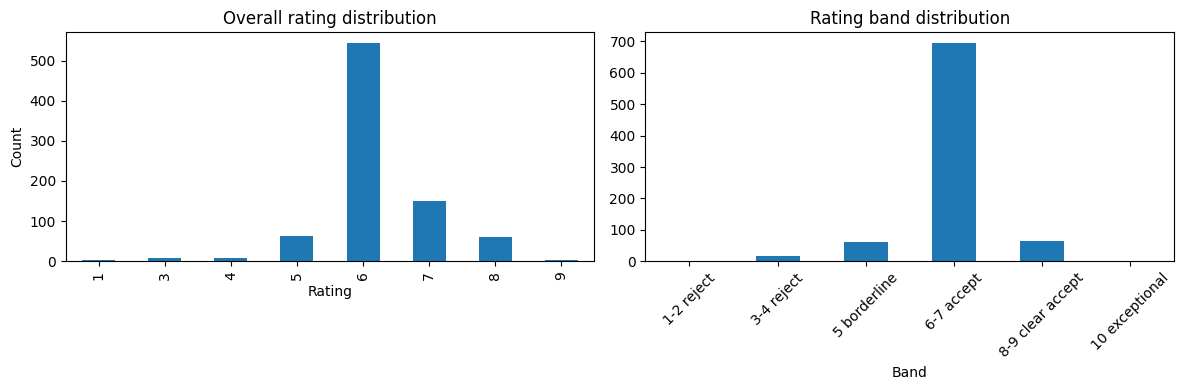

In [6]:
(fig, axes) = plt.subplots(1, 2, figsize=(12, 4))
reviews_df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Overall rating distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
band_order = [b[2] for b in RATING_BANDS]
reviews_df['rating_band'].value_counts().reindex(band_order).fillna(0).plot(kind='bar', ax=axes[1])
axes[1].set_title('Rating band distribution')
axes[1].set_xlabel('Band')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Inter-Reviewer Agreement

count    280.000000
mean       0.564520
std        0.454597
min        0.000000
25%        0.000000
50%        0.471405
75%        0.816497
max        2.357023
Name: std_rating, dtype: float64
Papers where all reviewers agree within 1 point: 62.5%


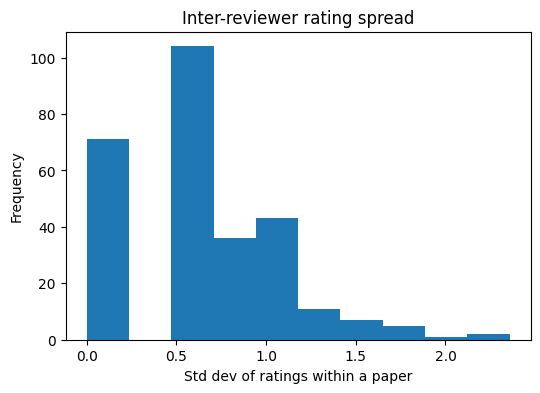

In [7]:
print(papers_df['std_rating'].describe())
within_1_point = (papers_df['max_rating'] - papers_df['min_rating'] <= 1).mean()
print(f'Papers where all reviewers agree within 1 point: {within_1_point:.1%}')
(fig, ax) = plt.subplots(figsize=(6, 4))
papers_df['std_rating'].plot(kind='hist', bins=10, ax=ax)
ax.set_xlabel('Std dev of ratings within a paper')
ax.set_title('Inter-reviewer rating spread')
plt.show()

## Weakness-Category Analysis

category
missing_baselines             0.477381
scalability                   0.326190
novelty_concern               0.309524
limited_datasets              0.294048
generalization                0.210714
hyperparameter_sensitivity    0.185714
no_ablation                   0.171429
theoretical_gap               0.117857
reproducibility               0.004762
Name: count, dtype: float64


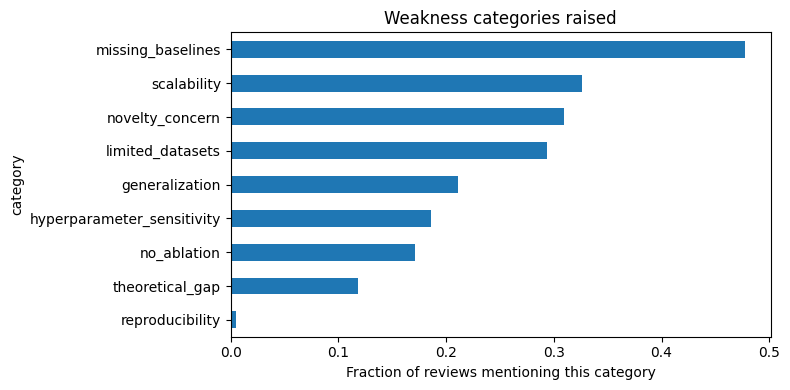

In [8]:
WEAKNESS_KEYWORDS = {'missing_baselines': ['baseline', 'compar'], 'limited_datasets': ['single dataset', 'one dataset', 'limited to', 'only evaluated on'], 'no_ablation': ['ablation'], 'hyperparameter_sensitivity': ['hyperparameter', 'sensitivit'], 'scalability': ['scalab', 'computational overhead', 'computational cost'], 'generalization': ['generaliz'], 'theoretical_gap': ['theoretical', 'assumption'], 'novelty_concern': ['novel', 'prior work', 'related work'], 'reproducibility': ['reproducib', 'implementation detail']}

def categorize_weaknesses(weaknesses: list[str]) -> set[str]:
    text = ' '.join(weaknesses).lower()
    return {cat for (cat, kws) in WEAKNESS_KEYWORDS.items() if any((kw in text for kw in kws))}
category_rows = []
for paper in papers_raw:
    for run in paper['reviews']:
        official = run['official_review']
        cats = categorize_weaknesses(official.get('extracted_weaknesses', []))
        for cat in cats:
            category_rows.append({'paper_id': paper['paper_id'], 'reviewer_model': official.get('reviewer_model'), 'category': cat})
categories_df = pd.DataFrame(category_rows)
n_reviews = len(reviews_df)
freq = categories_df['category'].value_counts() / n_reviews
print(freq)
(fig, ax) = plt.subplots(figsize=(8, 4))
freq.sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Fraction of reviews mentioning this category')
ax.set_title('Weakness categories raised')
plt.tight_layout()
plt.show()

In [9]:
category_by_model = categories_df.groupby(['reviewer_model', 'category']).size().unstack(fill_value=0)
category_by_model

category,generalization,hyperparameter_sensitivity,limited_datasets,missing_baselines,no_ablation,novelty_concern,reproducibility,scalability,theoretical_gap
reviewer_model,,,,,,,,,
llama3.1:8b,49,53,17,41,3,18,0,107,29
phi4-reasoning:14b,57,93,55,90,97,11,4,133,51
qwen3:14b,71,10,175,270,44,231,0,34,19


## Area Chair Decisions vs. Ratings

In [10]:
print(papers_df['decision'].value_counts())
print(papers_df.groupby('decision')['mean_rating'].describe())
papers_df['is_inconsistent'] = (papers_df['decision'] == 'accept') & (papers_df['mean_rating'] < 5) | (papers_df['decision'] == 'reject') & (papers_df['mean_rating'] >= 6)
print(f"Papers where AC decision looks inconsistent with mean rating: {papers_df['is_inconsistent'].sum()}")

decision
reject    242
accept     38
Name: count, dtype: int64
          count      mean       std       min       25%       50%       75%  \
decision                                                                      
accept     38.0  6.552632  0.331312  6.000000  6.333333  6.666667  6.666667   
reject    242.0  6.147383  0.459363  4.333333  6.000000  6.000000  6.333333   

               max  
decision            
accept    7.333333  
reject    7.000000  
Papers where AC decision looks inconsistent with mean rating: 194


## Sankey visualisation

- Generator to Rating Band to Decision

In [11]:
paper_gen_df = papers_df[['paper_id', 'generator_model', 'decision']].dropna(subset=['generator_model', 'decision'])
paper_level_df = paper_gen_df.merge(papers_df[['paper_id', 'mean_rating']], on='paper_id', how='inner')
paper_level_df['rating_band'] = paper_level_df['mean_rating'].round().apply(band_label)
print(f'Papers with generator, rating, and decision all resolved: {len(paper_level_df)}')
print(paper_level_df['rating_band'].value_counts())

Papers with generator, rating, and decision all resolved: 280
rating_band
6-7 accept      265
5 borderline     13
3-4 reject        2
Name: count, dtype: int64


In [12]:
band_order = [b[2] for b in RATING_BANDS]
present_bands = [b for b in band_order if b in paper_level_df["rating_band"].unique()]

generators = sorted(paper_level_df["generator_model"].unique())
decision_labels = ["accept", "reject"]

all_labels = generators + present_bands + decision_labels
label_to_idx = {label: i for i, label in enumerate(all_labels)}

flow1 = paper_level_df.groupby(["generator_model", "rating_band"]).size().reset_index(name="count")
flow2 = paper_level_df.groupby(["rating_band", "decision"]).size().reset_index(name="count")

sources, targets, values, link_colors = [], [], [], []

for _, row in flow1.iterrows():
    sources.append(label_to_idx[row["generator_model"]])
    targets.append(label_to_idx[row["rating_band"]])
    values.append(row["count"])
    link_colors.append("rgba(140,140,140,0.3)")

for _, row in flow2.iterrows():
    sources.append(label_to_idx[row["rating_band"]])
    targets.append(label_to_idx[row["decision"]])
    values.append(row["count"])
    link_colors.append(
        "rgba(84,162,75,0.35)" if row["decision"] == "accept" else "rgba(228,87,86,0.25)"
    )

node_colors = (
    ["#4C78A8"] * len(generators)      # generators: blue
    + ["#F2B701"] * len(present_bands)  # rating bands: yellow
    + ["#54A24B", "#E45756"]            # accept: green, reject: red
)

fig = go.Figure(data=[go.Sankey(
    node=dict(pad=15, thickness=18, line=dict(color="black", width=0.5),
              label=all_labels, color=node_colors),
    link=dict(source=sources, target=targets, value=values, color=link_colors),
)])
fig.update_layout(title_text="Generator model -> Mean Rating Band -> Decision", font_size=11)
fig.show()

## Generator self-enhancement and Area Chair self-alignment

In [13]:
valid_gen = reviews_df.dropna(subset=['generator_model'])
print(valid_gen.groupby(['reviewer_model', 'is_self_review'])['rating'].agg(['count', 'mean', 'std']),"\n")
for model in valid_gen['reviewer_model'].unique():
    subset = valid_gen[valid_gen['reviewer_model'] == model]
    self_ratings = subset.loc[subset['is_self_review'], 'rating']
    other_ratings = subset.loc[~subset['is_self_review'], 'rating']
    if len(self_ratings) == 0:
        print(f'{model}: no self-reviewed papers found in this sample -- cannot test.')
        continue
    diff = self_ratings.mean() - other_ratings.mean()
    print(f'{model}: self-review mean={self_ratings.mean():.2f} (n={len(self_ratings)}), other-review mean={other_ratings.mean():.2f} (n={len(other_ratings)}), difference={diff:+.2f}')

                                   count      mean       std
reviewer_model     is_self_review                           
llama3.1:8b        False             240  6.483333  1.230596
                   True               40  5.550000  1.175607
phi4-reasoning:14b False             240  6.058333  0.553359
                   True               40  5.625000  0.740322
qwen3:14b          False             240  6.237500  0.436142
                   True               40  6.400000  0.496139 

llama3.1:8b: self-review mean=5.55 (n=40), other-review mean=6.48 (n=240), difference=-0.93
qwen3:14b: self-review mean=6.40 (n=40), other-review mean=6.24 (n=240), difference=+0.16
phi4-reasoning:14b: self-review mean=5.62 (n=40), other-review mean=6.06 (n=240), difference=-0.43


In [14]:
paper_has_self_reviewer = reviews_df.groupby('paper_id')['is_self_review'].any()
papers_df['has_self_reviewer'] = papers_df['paper_id'].map(paper_has_self_reviewer)
papers_df['accept_binary'] = (papers_df['decision'] == 'accept').astype(int)
print(papers_df.groupby('has_self_reviewer')['accept_binary'].agg(['count', 'mean']))

                   count   mean
has_self_reviewer              
False                160  0.125
True                 120  0.150


In [15]:
for model in valid_gen['reviewer_model'].unique():
    subset = valid_gen[valid_gen['reviewer_model'] == model]
    self_ratings = subset.loc[subset['is_self_review'], 'rating']
    other_ratings = subset.loc[~subset['is_self_review'], 'rating']
    if len(self_ratings) < 2:
        continue
    (t_stat, p_value) = stats.ttest_ind(self_ratings, other_ratings, equal_var=False)
    print(f"{model}:\n diff={self_ratings.mean() - other_ratings.mean():+.2f}, t={t_stat:.2f}, p={p_value:.4f}, {('significant' if p_value < 0.05 else 'not significant')} at α=0.05")

llama3.1:8b:
 diff=-0.93, t=-4.62, p=0.0000, significant at α=0.05
qwen3:14b:
 diff=+0.16, t=1.95, p=0.0569, not significant at α=0.05
phi4-reasoning:14b:
 diff=-0.43, t=-3.54, p=0.0009, significant at α=0.05


### Area Chair self-alignment

In [16]:
self_align_rows = []
for paper in papers_raw:
    ac_model = paper.get('area_chair_model')
    decision = paper.get('meta_review', {}).get('decision')
    ratings_by_model = {}
    for run in paper['reviews']:
        official = run['official_review']
        ratings_by_model[official.get('reviewer_model')] = official.get('rating')
    self_rating = ratings_by_model.get(ac_model)
    other_ratings = [r for (m, r) in ratings_by_model.items() if m != ac_model and r is not None]
    self_align_rows.append({'paper_id': paper['paper_id'], 'ac_model': ac_model, 'decision': decision, 'self_rating': self_rating, 'other_mean_rating': statistics.mean(other_ratings) if other_ratings else None, 'self_minus_other': self_rating - statistics.mean(other_ratings) if self_rating is not None and other_ratings else None})
self_align_df = pd.DataFrame(self_align_rows)
self_align_df['decision_binary'] = (self_align_df['decision'] == 'accept').astype(int)

In [17]:
df = self_align_df.dropna(subset=["self_rating", "other_mean_rating", "decision"]).copy()

df["decision_binary"] = (
    df["decision"]
    .str.strip()
    .str.lower()
    .str.startswith("accept")
    .astype(int)
)

self_rating = df["self_rating"].to_numpy()
other_rating = df["other_mean_rating"].to_numpy()
decision = df["decision_binary"].to_numpy()

# Observed correlations
r_self = np.corrcoef(self_rating, decision)[0, 1]
r_other = np.corrcoef(other_rating, decision)[0, 1]
observed_difference = r_self - r_other

# Bootstrap the difference between correlations
rng = np.random.default_rng(42)
bootstrap_differences = []

for _ in range(10_000):
    indices = rng.integers(0, len(df), len(df))

    boot_self = np.corrcoef(
        self_rating[indices], decision[indices]
    )[0, 1]

    boot_other = np.corrcoef(
        other_rating[indices], decision[indices]
    )[0, 1]

    bootstrap_differences.append(boot_self - boot_other)

bootstrap_differences = np.asarray(bootstrap_differences)

ci_low, ci_high = np.percentile(
    bootstrap_differences, [2.5, 97.5]
)

p_value = 2 * min(
    np.mean(bootstrap_differences <= 0),
    np.mean(bootstrap_differences >= 0)
)

print(f"Correlation between AC's own rating and decision::                 {r_self:.3f}")
print(f"Correlation between other reviewers' mean rating and decision:     {r_other:.3f}")
print(f"Difference:                                                        {observed_difference:+.3f}")
print(f"95% bootstrap CI:                                                 [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Two-sided bootstrap p-value:                                       {p_value:.4f}")

Correlation between AC's own rating and decision::                 0.193
Correlation between other reviewers' mean rating and decision:     0.230
Difference:                                                        -0.036
95% bootstrap CI:                                                 [-0.220, 0.147]
Two-sided bootstrap p-value:                                       0.6884


## Convergence vs Justification (faithfulness check)

In [18]:
EMBED_MODEL = 'nomic-embed-text'
EMBED_SAMPLE_SIZE = None
paper_reviewer_texts = {}
for paper in papers_raw:
    texts = []
    for run in paper['reviews']:
        ws = run['official_review'].get('extracted_weaknesses', []) or []
        joined = ' '.join((w for w in ws if w)).strip()
        if joined:
            texts.append(joined)
    if len(texts) >= 2:
        paper_reviewer_texts[paper['paper_id']] = texts
pids = list(paper_reviewer_texts)
_dec = papers_df.set_index('paper_id')['decision'].to_dict()
if EMBED_SAMPLE_SIZE and len(pids) > EMBED_SAMPLE_SIZE:
    random.seed(42)
    accepts = [p for p in pids if _dec.get(p) == 'accept']
    rejects = [p for p in pids if _dec.get(p) == 'reject']
    pids = accepts + random.sample(rejects, max(0, EMBED_SAMPLE_SIZE - len(accepts)))

def _cos(a, b):
    (a, b) = (np.asarray(a), np.asarray(b))
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))
emb_rows = []
for pid in pids:
    vecs = ollama.embed(model=EMBED_MODEL, input=paper_reviewer_texts[pid])['embeddings']
    sims = [_cos(vecs[a], vecs[b]) for a in range(len(vecs)) for b in range(a + 1, len(vecs))]
    emb_rows.append({'paper_id': pid, 'mean_cosine': sum(sims) / len(sims)})
emb_df = pd.DataFrame(emb_rows).merge(papers_df[['paper_id', 'decision']], on='paper_id', how='left')
emb_df = emb_df.dropna(subset=['decision'])
print(emb_df.groupby('decision')['mean_cosine'].agg(['count', 'mean', 'median', 'std']))

          count      mean    median       std
decision                                     
accept       38  0.672361  0.660787  0.064741
reject      242  0.675481  0.671476  0.058632


reject: n=242, mean cosine=0.675
accept: n=38, mean cosine=0.672
Mann-Whitney U (H1: rejected MORE convergent): p = 0.3399


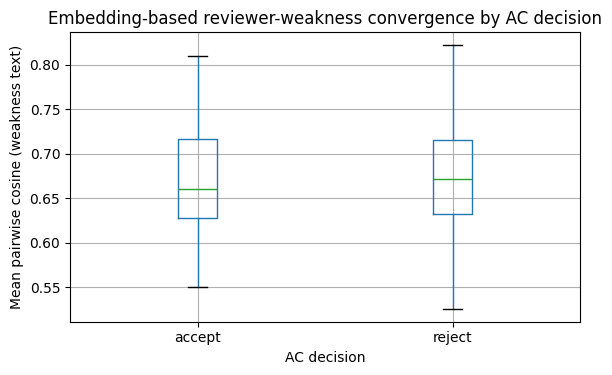

In [19]:
rej = emb_df.loc[emb_df['decision'] == 'reject', 'mean_cosine']
acc = emb_df.loc[emb_df['decision'] == 'accept', 'mean_cosine']
if len(rej) >= 3 and len(acc) >= 3:
    (u, p) = stats.mannwhitneyu(rej, acc, alternative='greater')
    print(f'reject: n={len(rej)}, mean cosine={rej.mean():.3f}')
    print(f'accept: n={len(acc)}, mean cosine={acc.mean():.3f}')
    print(f'Mann-Whitney U (H1: rejected MORE convergent): p = {p:.4f}')
    (fig, ax) = plt.subplots(figsize=(6, 4))
    emb_df.boxplot(column='mean_cosine', by='decision', ax=ax)
    ax.set_title('Embedding-based reviewer-weakness convergence by AC decision')
    ax.set_xlabel('AC decision')
    ax.set_ylabel('Mean pairwise cosine (weakness text)')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()
else:
    print(f'Not enough papers to test (reject n={len(rej)}, accept n={len(acc)}).')

## Comparison Against Real ICLR Reviews

Real ICLR ratings: n=4329, mean=5.44, stdev=1.49
Generated ratings: n=840, mean=6.20, stdev=0.86


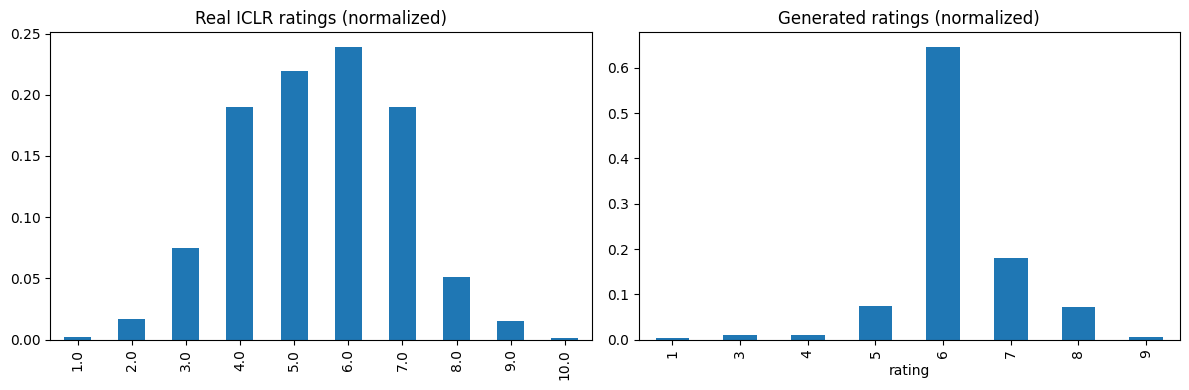

In [20]:
if ICLR_DB_PATH:
    conn = sqlite3.connect(ICLR_DB_PATH)
    real_ratings = [r[0] for r in conn.execute('SELECT rating FROM reviews WHERE rating IS NOT NULL').fetchall()]
    conn.close()
    print(f'Real ICLR ratings: n={len(real_ratings)}, mean={statistics.mean(real_ratings):.2f}, stdev={statistics.pstdev(real_ratings):.2f}')
    print(f"Generated ratings: n={len(reviews_df)}, mean={reviews_df['rating'].mean():.2f}, stdev={reviews_df['rating'].std():.2f}")
    (fig, axes) = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    pd.Series(real_ratings).value_counts(normalize=True).sort_index().plot(kind='bar', ax=axes[0])
    axes[0].set_title('Real ICLR ratings (normalized)')
    reviews_df['rating'].value_counts(normalize=True).sort_index().plot(kind='bar', ax=axes[1])
    axes[1].set_title('Generated ratings (normalized)')
    plt.tight_layout()
    plt.show()

In [21]:
gen_accept_rate = (papers_df['decision'] == 'accept').mean()
print(f"Generated pipeline accept rate: {gen_accept_rate:.1%} ({(papers_df['decision'] == 'accept').sum()} / {papers_df['decision'].notna().sum()})")
if ICLR_DB_PATH:
    try:
        with sqlite3.connect(ICLR_DB_PATH) as conn:
            n_real_decided, n_real_accepted = conn.execute("""
                SELECT COUNT(*) AS n_decided, SUM(CASE WHEN LOWER(TRIM(decision)) LIKE 'accept%' THEN 1 ELSE 0 END) AS n_accepted FROM paper_decisions WHERE decision IS NOT NULL AND TRIM(decision) <> '' """).fetchone()

        n_real_accepted = n_real_accepted or 0

        if n_real_decided > 0:
            real_accept_rate = n_real_accepted / n_real_decided

            print(
                f"Real ICLR accept rate:          "
                f"{real_accept_rate:.1%} "
                f"({n_real_accepted} / {n_real_decided})"
            )
        else:
            print("No ICLR decisions were found in paper_decisions.")

    except Exception as e:
        print(f"Could not read decisions from ICLR DB: {e}")

Generated pipeline accept rate: 13.6% (38 / 280)
Real ICLR accept rate:          35.4% (502 / 1418)


                            generated  real_ICLR    gap
missing_baselines               0.477      0.613 -0.136
scalability                     0.326      0.049  0.277
novelty_concern                 0.310      0.434 -0.125
limited_datasets                0.294      0.030  0.264
generalization                  0.211      0.154  0.057
hyperparameter_sensitivity      0.186      0.080  0.105
no_ablation                     0.171      0.072  0.100
theoretical_gap                 0.118      0.262 -0.144
reproducibility                 0.005      0.027 -0.023


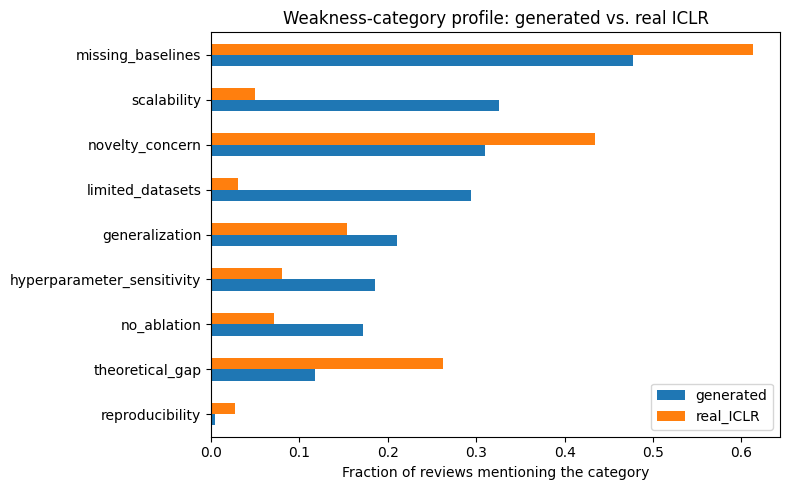

In [22]:
if ICLR_DB_PATH:
    try:
        conn = sqlite3.connect(ICLR_DB_PATH)
        real_texts = [r[0] for r in conn.execute('SELECT review_text FROM reviews WHERE review_text IS NOT NULL').fetchall()]
        conn.close()
        real_cat_counts = Counter()
        for t in real_texts:
            for cat in categorize_weaknesses([t]):
                real_cat_counts[cat] += 1
        real_freq = pd.Series(real_cat_counts) / len(real_texts)
        gen_freq = categories_df['category'].value_counts() / len(reviews_df)
        compare = pd.DataFrame({'generated': gen_freq, 'real_ICLR': real_freq}).fillna(0)
        compare['gap'] = compare['generated'] - compare['real_ICLR']
        print(compare.sort_values('generated', ascending=False).round(3))
        compare[['generated', 'real_ICLR']].sort_values('generated').plot(kind='barh', figsize=(8, 5))
        plt.xlabel('Fraction of reviews mentioning the category')
        plt.title('Weakness-category profile: generated vs. real ICLR')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f'Could not run weakness-profile comparison ({e}).')